In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/betabluindev/cleaned-combined-dataset/cleaned_emotion_dataset.csv


# **Installing Dependencies**
---

In [2]:
!pip install -q transformers datasets evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


# **Loading Dataset**
---

In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/betabluindev/cleaned-combined-dataset/cleaned_emotion_dataset.csv")

df = df.rename(columns={
    'clean_text': 'text',
    'final_label': 'label'
})

print(df.head())

                                                text  label
0  lt steve between his feet feeling a blush stin...  anger
1  i remember reading it and feeling so envious o...  anger
2  im feeling a little too violent and my mother ...  anger
3  i still get surprised when i wake up feeling h...  anger
4  i didn t feel like i was impatient there last ...  anger


# **Label Encoding**
---

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

num_labels = len(le.classes_)
print(le.classes_)

['anger' 'disgust' 'fear' 'joy' 'neutral' 'sadness' 'surprise']


# **Train-Test Split**
---

In [5]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'],
    df['label'],
    test_size=0.1,
    stratify=df['label'],
    random_state=42
)

# **Convert to HuggingFace Dataset**
---

In [6]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": train_texts.tolist(),
    "label": train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    "text": val_texts.tolist(),
    "label": val_labels.tolist()
})

# **Tokenization Function**
---

In [7]:
from transformers import AutoTokenizer

def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# **Metrics**
---

In [14]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    
    preds = logits.argmax(axis=1)
    
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

# **Training Models**
---

## **RoBERTa**

### **Training Function**

In [9]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

def train_model(model_name):
    
    global tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_val = val_dataset.map(tokenize_function, batched=True)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    
    from transformers import DataCollatorWithPadding
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    training_args = TrainingArguments(
        output_dir=f"./results_{model_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_dir="./logs",
        logging_steps=50,
        report_to ="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1"
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )
    
    trainer.train()
    
    results = trainer.evaluate()
    
    return trainer, results, tokenized_val   

In [10]:
roberta_trainer, roberta_results, tokenized_val = train_model("roberta-base")
print(roberta_results)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'eval_loss': 1.7369675636291504, 'eval_accuracy': 0.7178981937602628, 'eval_f1': 0.7190154767375075, 'eval_runtime': 30.123, 'eval_samples_per_second': 202.171, 'eval_steps_per_second': 6.341, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.66      0.70       901
           1       0.62      0.63      0.62       678
           2       0.84      0.73      0.78       863
           3       0.75      0.74      0.74       952
           4       0.59      0.70      0.64       815
           5       0.73      0.74      0.74       959
           6       0.74      0.80      0.77       922

    accuracy                           0.72      6090
   macro avg       0.72      0.71      0.71      6090
weighted avg       0.72      0.72      0.72      6090



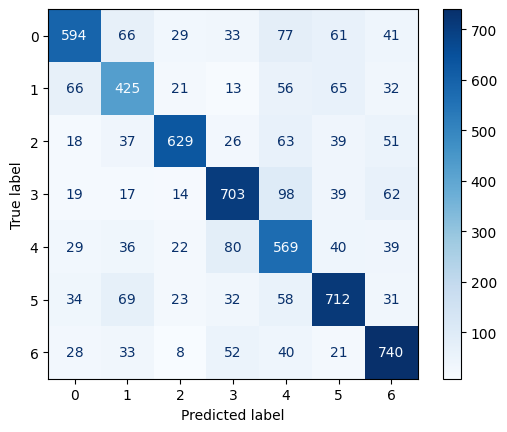

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Predictions
preds = roberta_trainer.predict(tokenized_val)
y_pred = preds.predictions.argmax(axis=1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(val_labels, y_pred))

# Confusion Matrix
cm = confusion_matrix(val_labels, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.show()



## **ELECTRA**

In [15]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

def train_model(model_name):
    
    global tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_val = val_dataset.map(tokenize_function, batched=True)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    
    from transformers import DataCollatorWithPadding
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    training_args = TrainingArguments(
        output_dir=f"./results_{model_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_dir="./logs",
        logging_steps=50,
        report_to ="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1"
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )
    
    trainer.train()
    
    results = trainer.evaluate()
    
    return trainer, results, tokenized_val   

In [17]:
electra_trainer, electra_results, tokenized_val = train_model("google/electra-base-discriminator")
print(electra_results)

Map:   0%|          | 0/54807 [00:00<?, ? examples/s]

Map:   0%|          | 0/6090 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.688301,1.845224,0.688342,0.690786
2,1.610349,1.746673,0.705747,0.707510
3,1.235527,1.788460,0.708703,0.710302


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

{'eval_loss': 1.7884604930877686, 'eval_accuracy': 0.7087027914614121, 'eval_f1': 0.7103019269514679, 'eval_runtime': 32.0872, 'eval_samples_per_second': 189.795, 'eval_steps_per_second': 5.953, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



Classification Report:

              precision    recall  f1-score   support

       anger       0.75      0.62      0.68       901
     disgust       0.60      0.66      0.63       678
        fear       0.83      0.72      0.77       863
         joy       0.74      0.72      0.73       952
     neutral       0.58      0.71      0.64       815
     sadness       0.73      0.73      0.73       959
    surprise       0.75      0.78      0.77       922

    accuracy                           0.71      6090
   macro avg       0.71      0.71      0.71      6090
weighted avg       0.72      0.71      0.71      6090



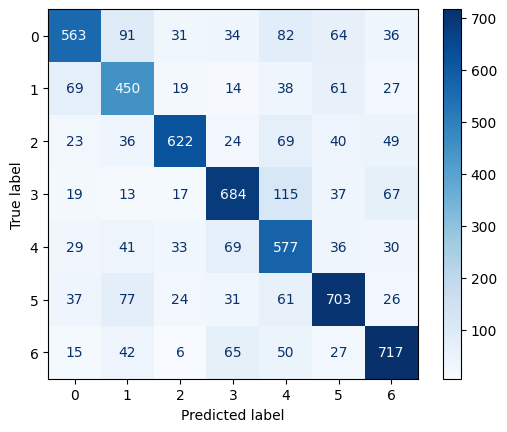

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds = electra_trainer.predict(tokenized_val)

y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.show()

## **ALBERT**

In [20]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

def train_model(model_name):
    
    global tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_val = val_dataset.map(tokenize_function, batched=True)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    
    from transformers import DataCollatorWithPadding
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    training_args = TrainingArguments(
        output_dir=f"./results_{model_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_dir="./logs",
        logging_steps=50,
        report_to ="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1"
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )
    
    trainer.train()
    
    results = trainer.evaluate()
    
    return trainer, results, tokenized_val   

In [21]:
albert_trainer, albert_results, tokenized_val = train_model("albert-base-v2")

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/54807 [00:00<?, ? examples/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['albert.embeddings.LayerNorm.weight', 'albert.embeddings.LayerNorm.bias', 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.LayerNorm.weight', 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['albert.embeddings.LayerNorm.beta', 'albert.embeddings.LayerNorm.gamma', 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.LayerNorm.beta', 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



Classification Report:

              precision    recall  f1-score   support

       anger       0.75      0.65      0.69       901
     disgust       0.56      0.63      0.60       678
        fear       0.80      0.70      0.75       863
         joy       0.73      0.71      0.72       952
     neutral       0.59      0.68      0.63       815
     sadness       0.71      0.73      0.72       959
    surprise       0.75      0.77      0.76       922

    accuracy                           0.70      6090
   macro avg       0.70      0.70      0.70      6090
weighted avg       0.71      0.70      0.70      6090



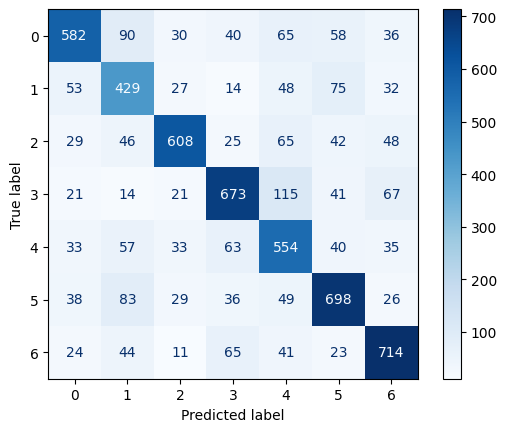

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds = albert_trainer.predict(tokenized_val)

y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.show()